In [1]:
import os
import pandas as pd
import random
import shutil

data_path = r'C:\Users\chloe\OneDrive\Desktop\swallow EMG\data\participants\1\extracted signals'

In [2]:
os.chdir("..") 
from src import feature_extraction, models, utils, results

exclude = ['oral prep 0']
df, class_map = feature_extraction.make_df(data_path, exclude)

df

substance volume         1                                              \
                           min       max        mav        rms    variance   
0           0     10  -89.8215   73.5244  10.123081  15.526914  241.085047   
1           0     10 -113.9200   86.1073   9.896790  16.791919  281.968302   
2           0     10  -82.3953   84.7438  10.532140  16.572327  274.641479   
3           0     10 -194.0030  125.6940  11.846242  20.842131  434.394440   
4           0     10 -117.7260   84.5021  11.854229  18.994828  360.801618   
..        ...    ...       ...       ...        ...        ...         ...   
440        10     20  -69.3289   69.5755  10.175371  15.426147  237.965865   
441        10     20  -86.3076   74.0248  11.288252  18.020237  324.728936   
442        10     20  -93.5527   91.9620  11.081596  17.163182  294.572930   
443        10     20  -95.3684   61.4933  11.031382  16.758005  280.830702   
444        10     20  -95.7571   91.9919  13.782139  20.737838  430.057924   

                                    ...            22                 \
     ssc     abs_diffs total_power  ...      variance  ssc abs_diffs   
0    432   8511.370464  307.637873  ...  2.147730e+07  130    426580   
1    440   8262.519721  347.467667  ...  2.476357e+07  117    449540   
2    427   8938.223938  335.785845  ...  3.078873e+07  147    391580   
3    432   9634.231501  503.956192  ...  4.119861e+07   94    458780   
4    394   9543.440074  450.438358  ...  4.449073e+07  121    353780   
..   ...           ...         ...  ...           ...  ...       ...   
440  396   8874.451929  312.405973  ...  1.854732e+07   95    329560   
441  421   9792.563997  432.794002  ...  2.879051e+07  137    396620   
442  417   8838.968969  368.683906  ...  2.811149e+07  109    390740   
443  390   9634.328738  345.837883  ...  2.616131e+07   90    390040   
444  403  11234.928474  547.324652  ...  2.290177e+07  120    462560   

                                                                \
      total_power     iemg shannon_entropy mean_freq peak_freq   
0    2.855146e+07  3322060        4.040291  7.067688       2.0   
1    2.839299e+07  4038860        4.537548  5.096151       1.0   
2    2.837819e+07  4577860        4.487950  4.361224       1.0   
3    2.361374e+07  5437880        4.410476  8.145964      13.0   
4    3.530921e+07  5531540        4.641191  3.729602       1.0   
..            ...      ...             ...       ...       ...   
440  2.012949e+07  3136980        3.997013  5.815702       3.0   
441  3.994745e+07  3865400        4.062512  5.177273       2.0   
442  3.174081e+07  4293940        4.641988  4.827547       3.0   
443  3.482336e+07  3813460        4.344892  5.345078       2.0   
444  2.527296e+07  3783080        4.518855  5.978335       3.0   

                                     
    spectral_edge_freq crest_factor  
0                 17.0     3.383382  
1                 16.0     2.549675  
2                 15.0     2.601074  
3                 16.0     3.326772  
4                 14.0     2.306773  
..                 ...          ...  
440               15.0     4.349148  
441               13.0     4.329699  
442               14.0     2.561073  
443               14.0     3.117836  
444               15.0     2.974145  

[445 rows x 310 columns]

In [3]:
print(class_map)

{'apple': 0, 'carrot': 1, 'chewing': 2, 'dry swallow': 3, 'grape': 4, 'jelly': 5, 'milk': 6, 'popcorn': 7, 'redu oral prep': 8, 'water': 9, 'yogurt': 10}


In [5]:
df_lim = df
all_acc = []

for i in range(6):
    if i > 0:
        df_lim = df_lim.groupby(['substance', 'volume']).apply(lambda x: x.sample(min(len(x), 5), random_state=42)).reset_index(drop=True)

    x = df_lim.drop(columns=['volume', 'substance'])
    y = df_lim[['substance', 'volume']]
    exact_accuracies, label_accuracies = models.train_multioutput_models(x, y, substance_names=class_map, random_state=42, show_cm=False, show_metrics=False)
    all_acc.append(exact_accuracies)

C:\Users\chloe\AppData\Local\Temp\ipykernel_28812\1540471959.py:8: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x = df_lim.drop(columns=['volume', 'substance'])
C:\Users\chloe\AppData\Local\Temp\ipykernel_28812\1540471959.py:6: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_lim = df_lim.groupby(['substance', 'volume']).apply(lambda x: x.sample(min(len(x), 5), random_state=42)).reset_index(drop=True)
C:\Users\chloe\AppData\Local\Temp\ipykernel_28812\1540471959.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_lim = df_lim.groupby(['substance', 'volume']).apply

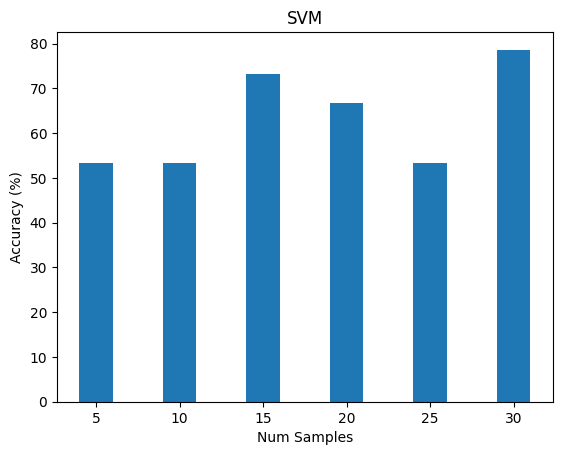

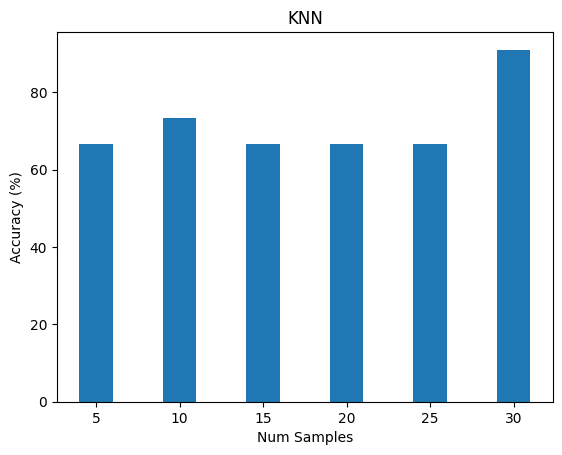

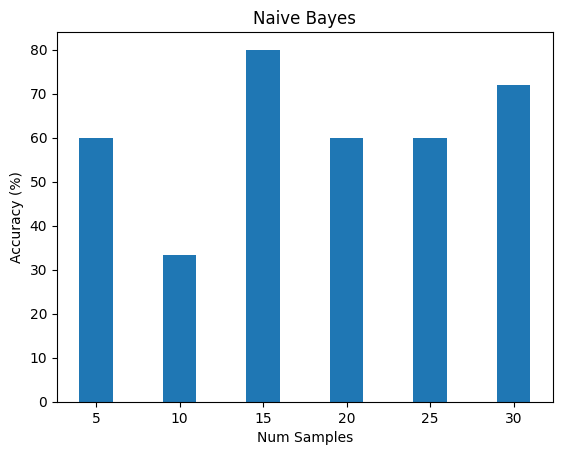

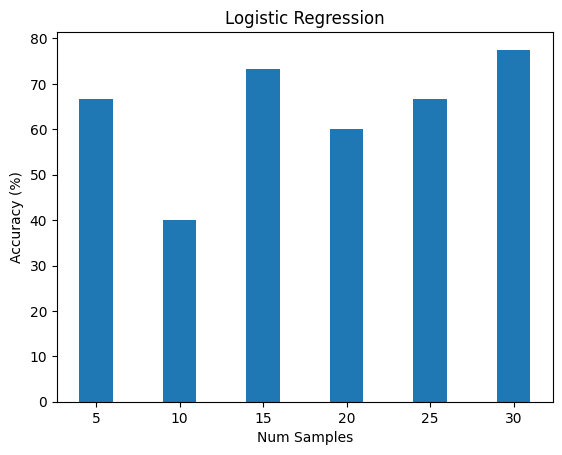

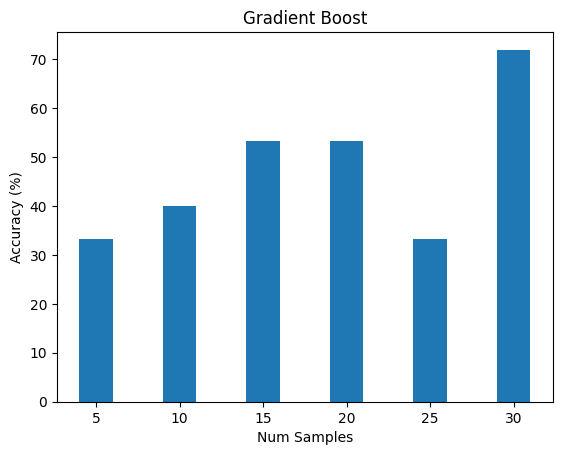

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from src.models import single_models

svm = [acc[0] for acc in all_acc]
knn = [acc[1] for acc in all_acc]
nb = [acc[2] for acc in all_acc]
lr = [acc[3] for acc in all_acc]
gb = [acc[4] for acc in all_acc]

sorted_accuracies = [svm, knn, nb, lr, gb]
model_names = [name for name, _ in single_models]
num_samples = [30, 25, 20, 15, 10, 5]

for i, acc in enumerate(sorted_accuracies):
    plt.title(model_names[i])
    plt.bar(num_samples, acc, width=2)

    plt.xlabel('Num Samples')
    plt.ylabel('Accuracy (%)')

    plt.show()

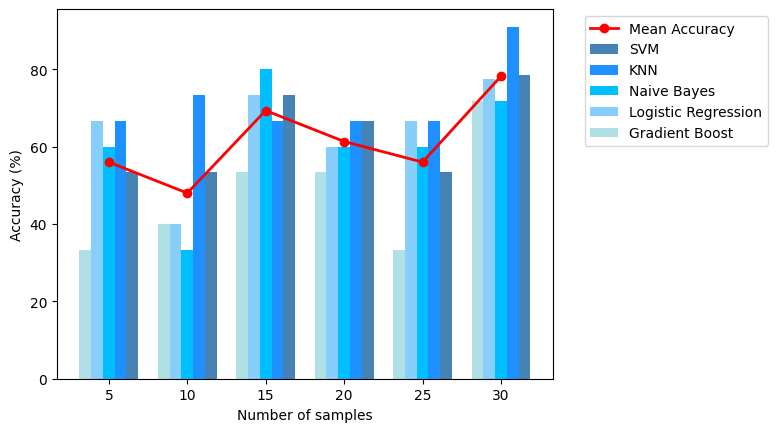

In [26]:
from sklearn.linear_model import LinearRegression

values = np.random.randint(5, 15, size=(len(num_samples), 5))
colors = ['steelblue','dodgerblue', 'deepskyblue', 'lightskyblue', 'powderblue']

x = np.arange(len(num_samples))

bar_width = 0.15

for i in range(5):
    plt.bar(x + i * bar_width, sorted_accuracies[i], width=bar_width, label=model_names[i], color=colors[i])

y_mean = np.mean(sorted_accuracies, axis=0)

plt.plot(x + bar_width * 2, y_mean, color="red", marker="o", linewidth=2, label="Mean Accuracy")

plt.xticks(x + bar_width * 2, num_samples) 
plt.xlabel("Number of samples")
plt.gca().invert_xaxis()
plt.ylabel("Accuracy (%)")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()